In [20]:
from pathlib import Path

import sys
if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=True)
    lab_root = Path("/content/drive/MyDrive/Colab Notebooks/DSML/Predictive_Project")
else:
    lab_root = Path(".")

print(f"lab_root set to: {lab_root.resolve()}")

lab_root set to: /Users/keni/dev/nova/machine-learning/ml-donors-prediction/keni


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    MinMaxScaler,
    OneHotEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    f1_score, roc_curve, roc_auc_score,
    precision_recall_curve,
)
from sklearn.model_selection import (
    StratifiedKFold, train_test_split, GridSearchCV,
    RandomizedSearchCV, PredefinedSplit, validation_curve,
    cross_validate, cross_val_predict
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from scipy.stats import spearmanr, chi2_contingency
from sklearn.feature_selection import RFE, mutual_info_classif
from sklearn.linear_model import LassoCV, LogisticRegressionCV, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [22]:
train_path = lab_root / "../data" / "donors_descriptive.csv"
train_target_path = lab_root / "../data" / "donors_train_target.csv"
test_path = lab_root / "../data" / "test.csv"

train = pd.read_csv(train_path, index_col="CONTROL_NUMBER")
target = pd.read_csv(train_target_path, index_col="CONTROL_NUMBER")
test = pd.read_csv(test_path, index_col="CONTROL_NUMBER")

--- Train Target distribution ---
TARGET_B
0    10170
1     3390
Name: count, dtype: int64
--- Train Target proportions ---
TARGET_B
0    0.75
1    0.25
Name: proportion, dtype: float64
Trivial 'predict-all-donors' F1 = 0.4000


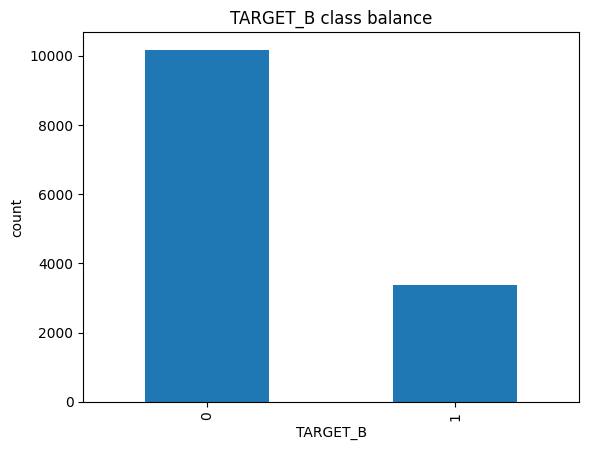

In [23]:
print("--- Train Target distribution ---")
counts = target["TARGET_B"].value_counts().sort_index()
print(counts)

print("--- Train Target proportions ---")
props  = target["TARGET_B"].value_counts(normalize=True).sort_index()
print(props.round(4))

trivial_all_ones_f1 = 2 * props.loc[1] / (1 + props.loc[1])  # F1 of predicting "donor" for everyone
print(f"Trivial 'predict-all-donors' F1 = {trivial_all_ones_f1:.4f}")

# Single visual (the only one needed here): class balance
counts.plot(kind="bar")
plt.title("TARGET_B class balance"); plt.xlabel("TARGET_B"); plt.ylabel("count"); plt.show()

In [24]:
%run _data_prep_func.ipynb

In [25]:
train = clean_descriptive(train)
train.head()

,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,...,SES,URBANICITY,WEALTH_RATING,PEP_STAR_IS_MISSING,FREQUENCY_STATUS_97NK_IS_MISSING,CHILDREN_IS_MISSING,RECENT_CARD_RESPONSE_COUNT_IS_MISSING,RECENT_RESPONSE_COUNT_IS_MISSING,CARD_PROM_12_IS_MISSING,DONOR_AGE_IS_MISSING
CONTROL_NUMBER,,,,,,,,,,,,,,,,,,,,,
61745,4,2,33,M,0,1,1,5,20.0,9,...,2,T,-1,0,0,0,0,0,0,0
112703,3,0,56,F,1,1,0,-1,15.0,6,...,3,R,-1,0,0,1,0,0,0,1
166437,4,0,74,F,7,3,1,4,10.0,17,...,1,U,-1,0,0,0,0,0,0,0
170621,4,4,61,M,13,1,1,6,11.0,28,...,1,U,-1,0,0,0,0,0,0,0
44428,6,3,75,M,3,4,1,3,7.0,9,...,2,C,-1,0,0,0,0,0,0,0


In [35]:
train.info()

<class 'pandas.DataFrame'>
Index: 13560 entries, 61745 to 45722
Data columns (total 46 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   CARD_PROM_12                           13560 non-null  int64  
 1   CHILDREN                               13560 non-null  int64  
 2   DONOR_AGE                              13560 non-null  int64  
 3   DONOR_GENDER                           13560 non-null  str    
 4   FILE_CARD_GIFT                         13560 non-null  int64  
 5   FREQUENCY_STATUS_97NK                  13560 non-null  int64  
 6   HOME_OWNER                             13560 non-null  int64  
 7   INCOME_GROUP                           13560 non-null  int64  
 8   LAST_GIFT_AMT                          13560 non-null  float64
 9   LIFETIME_CARD_PROM                     13560 non-null  int64  
 10  LIFETIME_GIFT_AMOUNT                   13560 non-null  float64
 11  LIFETIME_GIFT_

In [ ]:
modelling = train.join(target)
modelling.head()

,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,...,URBANICITY,WEALTH_RATING,PEP_STAR_IS_MISSING,FREQUENCY_STATUS_97NK_IS_MISSING,CHILDREN_IS_MISSING,RECENT_CARD_RESPONSE_COUNT_IS_MISSING,RECENT_RESPONSE_COUNT_IS_MISSING,CARD_PROM_12_IS_MISSING,DONOR_AGE_IS_MISSING,TARGET_B
CONTROL_NUMBER,,,,,,,,,,,,,,,,,,,,,
61745,4,2,33,M,0,1,1,5,20.0,9,...,T,-1,0,0,0,0,0,0,0,1
112703,3,0,56,F,1,1,0,-1,15.0,6,...,R,-1,0,0,1,0,0,0,1,1
166437,4,0,74,F,7,3,1,4,10.0,17,...,U,-1,0,0,0,0,0,0,0,0
170621,4,4,61,M,13,1,1,6,11.0,28,...,U,-1,0,0,0,0,0,0,0,0
44428,6,3,75,M,3,4,1,3,7.0,9,...,C,-1,0,0,0,0,0,0,0,0


In [ ]:
X = modelling.drop(columns="TARGET_B")
y = modelling["TARGET_B"].astype(int)
print(f"X shape: {X.shape}, y shape: {y.shape}")
print(y)

In [36]:
# binary_cols = X.select_dtypes(include="object").columns.tolist()
binary_cols = ['HOME_OWNER']
print("--- Binary columns ---")
print(binary_cols)
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
print("--- Numeric columns ---")
print(numeric_cols)
categorical_cols = [col for col in X.columns if col not in binary_cols + numeric_cols]
print("--- Categorical columns ---")
print(categorical_cols)

--- Binary columns ---
['HOME_OWNER']
--- Numeric columns ---
['CARD_PROM_12', 'CHILDREN', 'DONOR_AGE', 'FILE_CARD_GIFT', 'FREQUENCY_STATUS_97NK', 'HOME_OWNER', 'INCOME_GROUP', 'LAST_GIFT_AMT', 'LIFETIME_CARD_PROM', 'LIFETIME_GIFT_AMOUNT', 'LIFETIME_GIFT_COUNT', 'LIFETIME_MAX_GIFT_AMT', 'LIFETIME_MIN_GIFT_AMT', 'LIFETIME_PROM', 'MEDIAN_HOME_VALUE', 'MEDIAN_HOUSEHOLD_INCOME', 'MONTHS_SINCE_FIRST_GIFT', 'MONTHS_SINCE_LAST_GIFT', 'MONTHS_SINCE_LAST_PROM_RESP', 'NUMBER_PROM_12', 'PCT_ATTRIBUTE1', 'PCT_ATTRIBUTE2', 'PCT_ATTRIBUTE3', 'PCT_ATTRIBUTE4', 'PCT_OWNER_OCCUPIED', 'PEP_STAR', 'PER_CAPITA_INCOME', 'RECENT_AVG_CARD_GIFT_AMT', 'RECENT_AVG_GIFT_AMT', 'RECENT_CARD_RESPONSE_COUNT', 'RECENT_CARD_RESPONSE_PROP', 'RECENT_RESPONSE_COUNT', 'RECENT_RESPONSE_PROP', 'RECENT_STAR_STATUS', 'SES', 'WEALTH_RATING', 'PEP_STAR_IS_MISSING', 'FREQUENCY_STATUS_97NK_IS_MISSING', 'CHILDREN_IS_MISSING', 'RECENT_CARD_RESPONSE_COUNT_IS_MISSING', 'RECENT_RESPONSE_COUNT_IS_MISSING', 'CARD_PROM_12_IS_MISSING', 'D

In [ ]:
def make_preprocessor(numeric_imputer):
    """Numeric: impute (swappable) + scale.

    Categorical: most_frequent + one-hot (keeps "?" as a category).
    """
    num_pipe = Pipeline([("impute", numeric_imputer), ("scale",  MinMaxScaler())])
    cat_pipe = Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("ohe", OneHotEncoder(handle_unknown="ignore"))])
    return ColumnTransformer(
        [
            ("num", num_pipe, numeric_cols_X), 
            ("cat", cat_pipe, nominal_cat)
        ]
    )

# Baseline: simple median imputation. We later swap in IterativeImputer (MICE) and measure the gain,
# via make_preprocessor(IterativeImputer(random_state=RANDOM_SEED)).
preprocessor = make_preprocessor(SimpleImputer(strategy="median"))